In [1]:
# 1. 문제 정의
# 4909명의 건강 정보를 가지고 뇌졸중 유무를 판단하는 모델을 설계해보자!

In [2]:
# 라이브러리 불러오기가 우선!!
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# 2. 데이터 수집
# data 폴더에 csv 파일 추가하고, 해당 파일 불러오기!
data = pd.read_csv('./data/healthcare-dataset-stroke-data.csv')
data.set_index('id', inplace = True)
data
# 데이터 불러온 후에 'id' 컬럼을 index로 설정하기

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
id,,,,,,,,,,,
77,Female,13.0,0,0,No,children,Rural,85.81,18.6,Unknown,0
84,Male,55.0,0,0,Yes,Private,Urban,89.17,31.5,never smoked,0
91,Female,42.0,0,0,No,Private,Urban,98.53,18.5,never smoked,0
99,Female,31.0,0,0,No,Private,Urban,108.89,52.3,Unknown,0
129,Female,24.0,0,0,No,Private,Urban,97.55,26.2,never smoked,0
...,...,...,...,...,...,...,...,...,...,...,...
72911,Female,57.0,1,0,Yes,Private,Rural,129.54,60.9,smokes,0
72914,Female,19.0,0,0,No,Private,Urban,90.57,24.2,Unknown,0
72915,Female,45.0,0,0,Yes,Private,Urban,172.33,45.3,formerly smoked,0


In [4]:
# 데이터 정보 확인
data.info()

# 결측치 없음
# 10개의 입력 특성(X)과 1개의 정답데이터(y - stroke)를 가지고 있다.

<class 'pandas.DataFrame'>
Index: 4909 entries, 77 to 72940
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   gender             4909 non-null   str    
 1   age                4909 non-null   float64
 2   hypertension       4909 non-null   int64  
 3   heart_disease      4909 non-null   int64  
 4   ever_married       4909 non-null   str    
 5   work_type          4909 non-null   str    
 6   Residence_type     4909 non-null   str    
 7   avg_glucose_level  4909 non-null   float64
 8   bmi                4909 non-null   float64
 9   smoking_status     4909 non-null   str    
 10  stroke             4909 non-null   int64  
dtypes: float64(3), int64(3), str(5)
memory usage: 609.6 KB


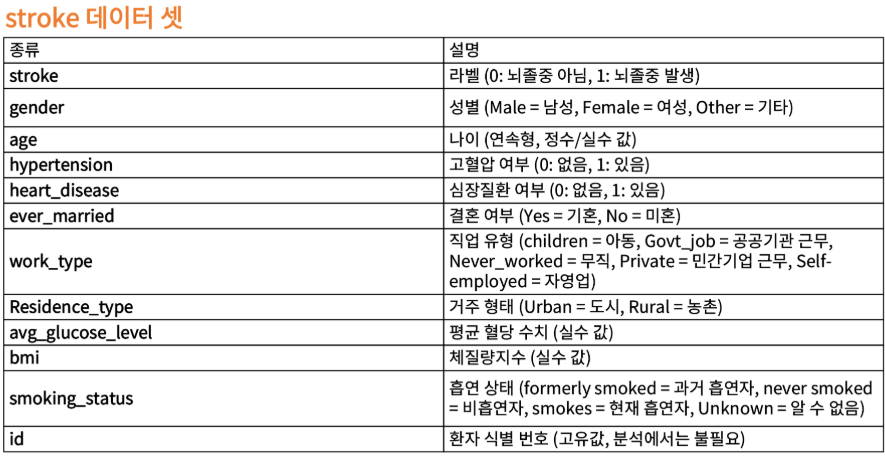

In [5]:
# 문제 데이터 / 정답 데이터 분리
X = data.drop('stroke', axis = 1)# stroke 컬럼 제외 나머지 다 선택.  #drop으로 빼버려도 됨
y = data['stroke']# stroke 컬럼

X.shape, y.shape # (4909, 10), (4909, )

((4909, 10), (4909,))

In [6]:
# 데이터 분리 - 훈련용 / 테스트용 7:3
# 슬라이싱 -> 안씀
# 대신 데이터 분리 도구 사용 -> train_test_split

# 데이터 분리 도구 불러오기(랜덤 샘플링 도구)
from sklearn.model_selection import train_test_split

In [7]:
# 분리한 후 나오는 결과값의 순서에 맞게 변수 순서를 올바르게 지정해야 한다!!
X_train, X_test, y_train, y_test = train_test_split(X, y, # 분리 대상(문제, 정답) 
                                                    test_size = 0.3, # 분리 비율 -> 7:3
                                                    random_state = 2026) # 랜덤 고정(숫자의 의미는 없음)
                                                                        # .seed() 랑 같은 역할

X_train.shape, X_test.shape, y_train.shape, y_test.shape
# 쉐잎 찍어서 꼭 확인해야할 3가지 항목
# 문제(X) 2차원 / 정답(y) 1차원
# 사용할 입력데이터 개수(컬럼 개수) - 10개
# 훈련용 / 평가용 데이터 행 개수 일치 하는지

((3436, 10), (1473, 10), (3436,), (1473,))

In [8]:
# 의사결정나무 불러오기
from sklearn.tree import DecisionTreeClassifier

In [9]:
# 모델 학습

dt_model = DecisionTreeClassifier()

dt_model.fit(X_train, y_train)

ValueError: could not convert string to float: 'Female'

In [10]:
# 학습이 되지 않는 이유 : 
# 머신러닝 모델은 수치형 데이터만 학습 가능 (정답 데이터는 상관 없음)

In [11]:
# 3. 데이터 전처리
# 데이터 이해하기
y.value_counts()
# 0 : 음성, 1 : 양성
# 결과를 보았을때 불균형한 데이터라면 추가적인 데이터 수집이 필요하다!

stroke
0    4700
1     209
Name: count, dtype: int64

In [12]:
# 기술통계량 확인 -> describe()
X.describe()

# 기본적으로는 수치형 데이터만 확인이 가능하다

,age,hypertension,heart_disease,avg_glucose_level,bmi
count,4909.000000,4909.000000,4909.000000,4909.000000,4909.000000
mean,42.865374,0.091872,0.049501,105.305150,28.893237
std,22.555115,0.288875,0.216934,44.424341,7.854067
min,0.080000,0.000000,0.000000,55.120000,10.300000
25%,25.000000,0.000000,0.000000,77.070000,23.500000
50%,44.000000,0.000000,0.000000,91.680000,28.100000
75%,60.000000,0.000000,0.000000,113.570000,33.100000
max,82.000000,1.000000,1.000000,271.740000,97.600000


In [13]:
# 문자열 데이터도 확인하고 싶다면?
X.describe(include = 'str')

,gender,ever_married,work_type,Residence_type,smoking_status
count,4909,4909,4909,4909,4909
unique,3,2,5,2,4
top,Female,Yes,Private,Urban,never smoked
freq,2897,3204,2811,2490,1852


In [14]:
X['gender'].unique()

<ArrowStringArray>
['Female', 'Male', 'Other']
Length: 3, dtype: str

##### 범주형 -> 수치형 데이터로 바꾸는 인코딩 작업이 필요!
- 인코딩 방법 : 라벨인코딩, 원핫인코딩
    - 라벨인코딩 : 각 값을 1:1로 매핑(EX> 'female : 0, 'male' : 1, 'other' : 2)
        - 값의 크고 작음의 의미가 있을 때(가중치가 있을때) 사용한다.
    - 원핫인코딩 : 범주의 종류만큼 자리(컬럼)를 만들고 단 한 개의 1과 나머지 0으로 채워서 숫자화
        - 값의 크고 작음의 의미가 없을 때

In [15]:
# 원핫인코딩 적용해보기
# pd.get_dummies(적용대상, dtype = int)
X_oh = pd.get_dummies(X, dtype = int)
X_oh

,age,hypertension,heart_disease,avg_glucose_level,bmi,gender_Female,gender_Male,gender_Other,ever_married_No,ever_married_Yes,...,work_type_Never_worked,work_type_Private,work_type_Self-employed,work_type_children,Residence_type_Rural,Residence_type_Urban,smoking_status_Unknown,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes
id,,,,,,,,,,,,,,,,,,,,,
77,13.0,0,0,85.81,18.6,1,0,0,1,0,...,0,0,0,1,1,0,1,0,0,0
84,55.0,0,0,89.17,31.5,0,1,0,0,1,...,0,1,0,0,0,1,0,0,1,0
91,42.0,0,0,98.53,18.5,1,0,0,1,0,...,0,1,0,0,0,1,0,0,1,0
99,31.0,0,0,108.89,52.3,1,0,0,1,0,...,0,1,0,0,0,1,1,0,0,0
129,24.0,0,0,97.55,26.2,1,0,0,1,0,...,0,1,0,0,0,1,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
72911,57.0,1,0,129.54,60.9,1,0,0,0,1,...,0,1,0,0,1,0,0,0,0,1
72914,19.0,0,0,90.57,24.2,1,0,0,1,0,...,0,1,0,0,0,1,1,0,0,0
72915,45.0,0,0,172.33,45.3,1,0,0,0,1,...,0,1,0,0,0,1,0,1,0,0


In [16]:
# 직접 모델 학습 시켜보기!!!
# train/test 분리 -> 원핫인코딩 진행한 문제데이터, 정답데이터
# 분리 도구 활용, 분리 비율 -> 7:3, 랜덤수 고정 17
A = X_oh
b = data['stroke']

A_train, A_test, b_train, b_test = train_test_split(A, b, test_size = 0.3,random_state = 17)

# 분리 후 데이터 모양 확인하기
A_train.shape, A_test.shape, b_train.shape, b_test.shape
# 훈련용 데이터 : 3436, 평가용 데이터 : 1473
# 사용하는 입력 특성(컬럼) : 21

((3436, 21), (1473, 21), (3436,), (1473,))

In [17]:
# 모델 선택 및 (하이퍼파라미터 조정)
# 의사결정나무 분류 모델

# 모델 객세 생성(변수 넣기)
dt_model = DecisionTreeClassifier(max_depth=3)
# 모델 학습 -> fit() 
dt_model.fit(A_train, b_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples a

In [36]:
# 혹시 학습 오류(unicode 관련)가 난다면 해당 셀 실행  ---> 아나콘다 프롬포트 켜서setx PYTHONUTF8 1이거 입력해서 이제 안해도 됨.
#from sklearn import set_config
#set_config(display = 'text')

In [18]:
# 학습데이터 평가 점수 확인
print(dt_model.score(A_train, b_train))
# 평가데이터 평가 점수 확인
print(dt_model.score(A_test, b_test))

0.9583818393480792
0.957909029192125


In [19]:
# ==========================================
# [ 머신러닝 모델 학습 및 평가 핵심 정리 ]
# ==========================================

# 1. 훈련용 점수가 1.0(100점)이 나오는 이유와 문제점 (과대적합, Overfitting)
# - 원인: 모델이 데이터를 현명하게 이해한 것이 아니라, 공부했던 문제와 정답을 통째로 '암기'해버린 상태입니다.
# - 문제점: 과대적합(Overfitting)이 발생하면, 한 번도 보지 못한 새로운 실전 데이터(테스트용 데이터)를 
#          풀게 했을 때 엉뚱한 오답을 내며 성능(점수)이 급격히 떨어지게 됩니다. (실전에 약한 모델)

# 2. 과대적합을 해결하기 위한 하이퍼파라미터 조정 방법
# - max_depth (최대 깊이 제한): 
#   트리가 너무 복잡하게 뻗어나가지 못하도록 깊이를 제한하여 '암기'를 방지합니다.
#   (예: max_depth=3 또는 max_depth=5 처럼 낮게 설정)
# - min_samples_split / min_samples_leaf: 
#   노드를 쪼개거나 잎사귀를 만들기 위한 최소 데이터 개수를 늘려 모델을 단순하게 만듭니다.
# - 결과: 훈련용 점수는 1.0(100점)보다 조금 낮아지더라도, 
#         실전 테스트용 점수가 더 높고 안정적으로 유지되는 균형 잡힌 모델을 만들 수 있습니다!

### 과대적합, 과소적합, 일반화
 - 과대적합(과적합)(overfitting) : 훈련데이터에 너무 과도하게 학습되어서 훈련데이터에만 잘 작동하고 평가데이터에서는 예측 성능이 저하하는 현상
 - 과소적합(underfitting) : 훈련데이터, 평가데이터 모두에서 예측 성능이 저하하는 현상(학습을 제대로 하지 못함)
 - 일반화(generalization) : 훈련데이터로 학습한 모델이 평가데이터에 대해서도 잘 예측하는 현상 -> 우리가 지향해야할 점
  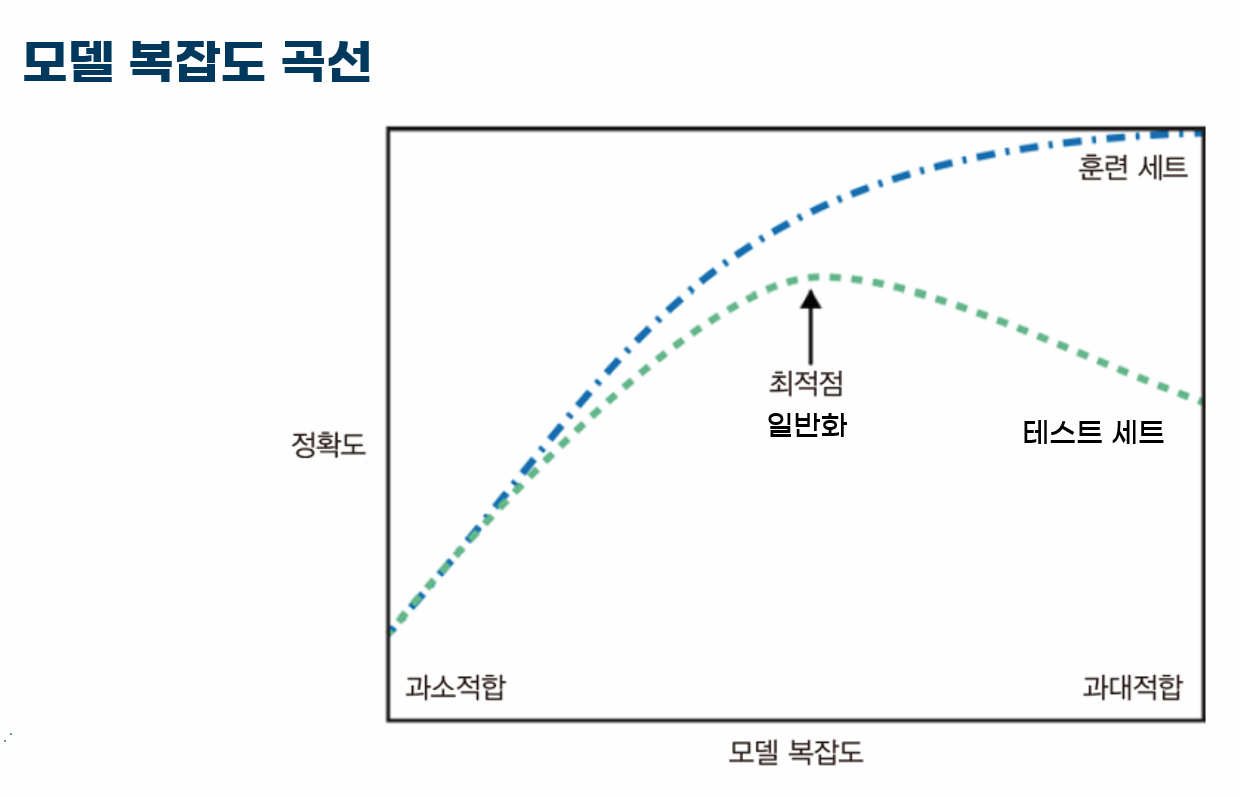

In [20]:
# 하이퍼파라미터 조절을 통한 과대적합 방지 해보기

# 모델링 
# 모델 객체 생성
dt_model2 = DecisionTreeClassifier(max_depth = 5, min_samples_split = 5)

# 모델 학습 및 평가
dt_model2.fit(A_train, b_train)

print(dt_model2.score(A_train, b_train))
print(dt_model2.score(A_test, b_test))

0.9610011641443539
0.957909029192125


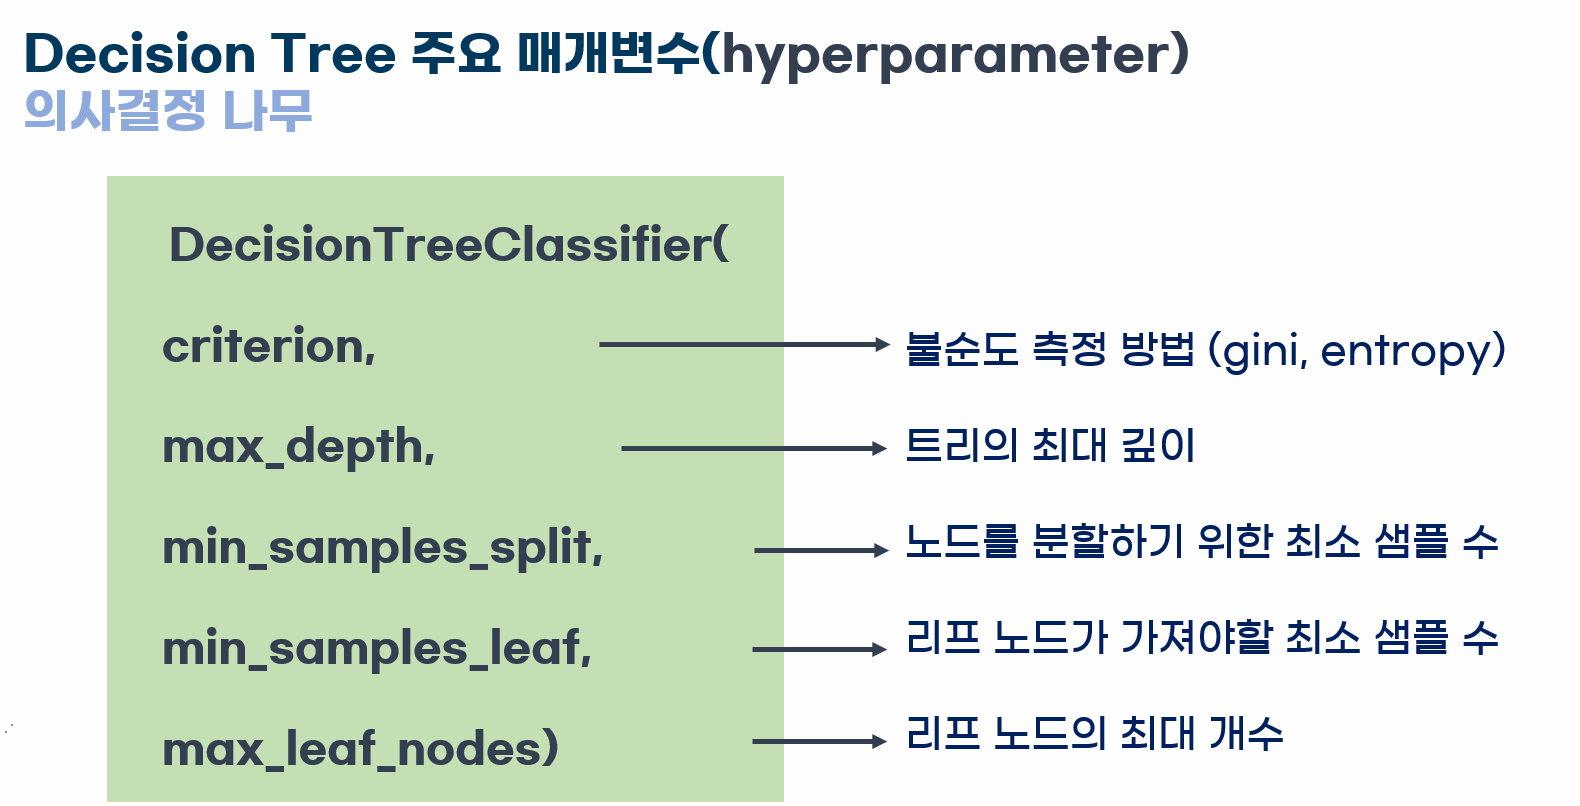

In [21]:
# 여러개의 의사결정나무 만들어보기
# 최적의 하이퍼파라미터 찾아서 공유해주기

In [22]:
# 반복문 활용해서 최적의 depth 값 찾기
for depth in range(1, 11):
    model = DecisionTreeClassifier(max_depth=depth, random_state=17)
    model.fit(A_train, b_train)
    
    train_score = model.score(A_train, b_train)
    test_score = model.score(A_test, b_test)
    
    print(f"max_depth={depth:2d} | 훈련 점수: {train_score:.4f} | 테스트 점수: {test_score:.4f}")

max_depth= 1 | 훈련 점수: 0.9572 | 테스트 점수: 0.9579
max_depth= 2 | 훈련 점수: 0.9572 | 테스트 점수: 0.9579
max_depth= 3 | 훈련 점수: 0.9584 | 테스트 점수: 0.9579
max_depth= 4 | 훈련 점수: 0.9593 | 테스트 점수: 0.9579
max_depth= 5 | 훈련 점수: 0.9613 | 테스트 점수: 0.9579
max_depth= 6 | 훈련 점수: 0.9659 | 테스트 점수: 0.9511
max_depth= 7 | 훈련 점수: 0.9697 | 테스트 점수: 0.9498
max_depth= 8 | 훈련 점수: 0.9750 | 테스트 점수: 0.9470
max_depth= 9 | 훈련 점수: 0.9796 | 테스트 점수: 0.9409
max_depth=10 | 훈련 점수: 0.9857 | 테스트 점수: 0.9389


In [23]:
# max_depth와 min_samples_split을 동시에 조절해보기
for depth in range(1, 6):
    for split in [2, 5, 10, 20]:
        model = DecisionTreeClassifier(
            max_depth=depth, 
            min_samples_split=split, 
            random_state=17
        )
        model.fit(A_train, b_train)
        
        train_score = model.score(A_train, b_train)
        test_score = model.score(A_test, b_test)
        
        print(f"depth: {depth} | split: {split:2d} --> 훈련: {train_score:.4f} | 테스트: {test_score:.4f}")

depth: 1 | split:  2 --> 훈련: 0.9572 | 테스트: 0.9579
depth: 1 | split:  5 --> 훈련: 0.9572 | 테스트: 0.9579
depth: 1 | split: 10 --> 훈련: 0.9572 | 테스트: 0.9579
depth: 1 | split: 20 --> 훈련: 0.9572 | 테스트: 0.9579
depth: 2 | split:  2 --> 훈련: 0.9572 | 테스트: 0.9579
depth: 2 | split:  5 --> 훈련: 0.9572 | 테스트: 0.9579
depth: 2 | split: 10 --> 훈련: 0.9572 | 테스트: 0.9579
depth: 2 | split: 20 --> 훈련: 0.9572 | 테스트: 0.9579
depth: 3 | split:  2 --> 훈련: 0.9584 | 테스트: 0.9579
depth: 3 | split:  5 --> 훈련: 0.9584 | 테스트: 0.9579
depth: 3 | split: 10 --> 훈련: 0.9584 | 테스트: 0.9579
depth: 3 | split: 20 --> 훈련: 0.9584 | 테스트: 0.9579
depth: 4 | split:  2 --> 훈련: 0.9593 | 테스트: 0.9579
depth: 4 | split:  5 --> 훈련: 0.9593 | 테스트: 0.9579
depth: 4 | split: 10 --> 훈련: 0.9593 | 테스트: 0.9579
depth: 4 | split: 20 --> 훈련: 0.9587 | 테스트: 0.9579
depth: 5 | split:  2 --> 훈련: 0.9613 | 테스트: 0.9579
depth: 5 | split:  5 --> 훈련: 0.9610 | 테스트: 0.9579
depth: 5 | split: 10 --> 훈련: 0.9607 | 테스트: 0.9579
depth: 5 | split: 20 --> 훈련: 0.9587 | 테스트: 0.9579


In [24]:
# 데이터가 많을 수록 과대적합을 제어할 수 있음
# 어떻게 하면 여러번의 검증을 실시할 수 있을까?
# 보유한 데이터를 여러 번 활용해서 검증해서 성능을 확인 : 교차검증(cross-validation)
# 모델의 일반화 정도를 확인하는데 사용

In [25]:
# 교차검증 도구 불러오기
from sklearn.model_selection import cross_val_score

In [26]:
# cross_val_score(모델명, 훈련용문제, 훈련용정답, cv = 교차검증횟수)
cross_val_score(dt_model, A_train, b_train, cv = 5)

array([0.95494186, 0.95778748, 0.95778748, 0.95778748, 0.95633188])

In [27]:
cross_val_score(dt_model2, A_train, b_train, cv = 5)

array([0.95348837, 0.95196507, 0.95196507, 0.95487627, 0.95196507])

In [28]:
# gridsearchCV -> 교차 검증을 통해서 하이퍼파라미터 최적의 조합을 찾는 도구

from sklearn.model_selection import GridSearchCV

In [30]:
# 1. 조정할 매개변수 설정 값 정의
params = {
    'max_depth' : [3, 5, 7],
    'max_leaf_nodes' : [4, 8],
    'min_samples_split' : [3, 5, 7],
    'min_samples_leaf' : [1, 2, 3]
}

# 2. 모델 객체 생성
model = DecisionTreeClassifier()

# 3. 그리드 서치 도구 객체 생성
grid = GridSearchCV(
    model, # 사용할 모델
    params, # 조정할 목록
    scoring = 'accuracy', # 사용할 평가 지표
    cv = 5 # 교차검증 횟수
)

# 4. 학습 실행
grid.fit(A_train, b_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [3, 5, ...], 'max_leaf_nodes': [4, 8], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [3, 5, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose 

In [31]:
# 가장 높은 성능일때의 모델의 하이퍼파라미터 조합 확인
grid.best_params_

{'max_depth': 3,
 'max_leaf_nodes': 4,
 'min_samples_leaf': 1,
 'min_samples_split': 3}

In [32]:
# 가장 높은 성능 확인
grid.best_score_

np.float64(0.9569272367218442)

In [33]:
# 트리모델 시각화
from sklearn.tree import plot_tree

# 차트에 한글을 출력하려면 인코딩 작업이 필요
from matplotlib import rc
rc('font', family = 'Malgun Gothic')

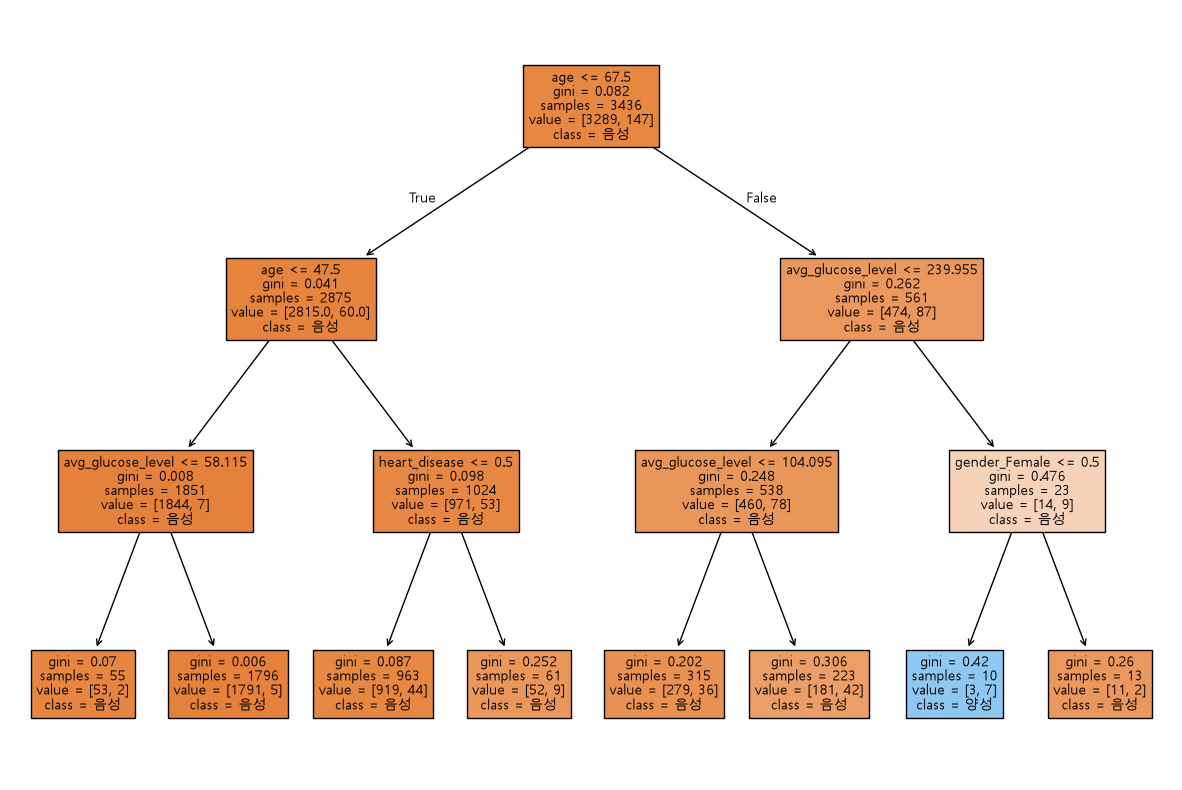

In [42]:
# 도화지 크기 조정(최상단에 작성할 것!!)
plt.figure(figsize = (15,10)) #(가로,세로)

plot_tree(
    dt_model, # 그릴 의사결정나무 모델
    feature_names = X_oh.columns, # 특성 이름 지정
    class_names = ['음성', '양성'], # 클래스 이름 지정
    filled = True, # 노드 색상 채우기
    fontsize = 10 # 글씨 쓰기
)
plt.show()

In [34]:
X_oh.columns

Index(['age', 'hypertension', 'heart_disease', 'avg_glucose_level', 'bmi',
       'gender_Female', 'gender_Male', 'gender_Other', 'ever_married_No',
       'ever_married_Yes', 'work_type_Govt_job', 'work_type_Never_worked',
       'work_type_Private', 'work_type_Self-employed', 'work_type_children',
       'Residence_type_Rural', 'Residence_type_Urban',
       'smoking_status_Unknown', 'smoking_status_formerly smoked',
       'smoking_status_never smoked', 'smoking_status_smokes'],
      dtype='str')

In [ ]:
# 왜 21개의 특성 중에서 age를 첫번째 질문으로 했을까?
# 21개의 특성들이 가지는 중요도를 살펴보도록 하자

### 특성 선택
 - 각 특성들의 중요도를 출력해보자
 - 정답에 얼마만큼 영향을 미치는 특성인지 수치로 확인
 - 각 특성 중요도는 0-1 사이의 값을 가진다
 - 모든 특성 중요도의 합은 1
 - tree 모델은 특성 중요도가 높은 값을 상위 질문으로 배치

In [44]:
# 모델의 특성 중요도 확인
fi = dt_model.feature_importances_
fi

array([0.69407585, 0.        , 0.04141711, 0.14716778, 0.        ,
       0.11733926, 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        ])

In [47]:
# 특성 중요도를 df화 해보자!
fi_df = pd.DataFrame(fi, index = X_oh.columns, columns = ['특성중요도'])
fi_df

,특성중요도
age,0.694076
hypertension,0.000000
heart_disease,0.041417
avg_glucose_level,0.147168
bmi,0.000000
gender_Female,0.117339
gender_Male,0.000000
gender_Other,0.000000
ever_married_No,0.000000
ever_married_Yes,0.000000


In [48]:
# 내림차순 정렬하기
fi_df.sort_values(by = '특성중요도', ascending = False)

,특성중요도
age,0.694076
avg_glucose_level,0.147168
gender_Female,0.117339
heart_disease,0.041417
hypertension,0.000000
bmi,0.000000
gender_Male,0.000000
gender_Other,0.000000
ever_married_No,0.000000
ever_married_Yes,0.000000


### 정리 
 - 트리 모델 시각화의 결과를 보면 age가 최상단 질문으로 배치되어 있음
 - 노드 선택 원리 : 트리는 각 단계에서 불순도 감소가 가장 큰 특성을 우선적으로 선택
 - 트리는 순간적으로 최적 선택만 하기 때문에, 최상단 노드와 특성 중요도 1위가 항상 일치하지는 않음
   (탐욕적(greedy) 특성)
 - 다만, 특성중요도가 높은 컬럼일수록 상위 질문으로 등장할 가능성이 크다